# Poisson Equation — FEniCSx Demo

Solve −Δu = f on the unit square with homogeneous Dirichlet BCs.
Exact solution: u(x,y) = 1 + x² + 2y²  with f = −6.

In [1]:
from mpi4py import MPI
import numpy as np
from dolfinx import mesh, fem, default_scalar_type
from dolfinx.fem.petsc import LinearProblem
from dolfinx.fem import functionspace, dirichletbc, locate_dofs_topological
from dolfinx.mesh import locate_entities_boundary
from ufl import TestFunction, TrialFunction, dx, grad, inner, SpatialCoordinate

In [2]:
domain = mesh.create_unit_square(MPI.COMM_WORLD, 8, 8)
V = functionspace(domain, ("Lagrange", 1))
print(f"Number of dofs: {V.dofmap.index_map.size_global}")

Number of dofs: 81


In [3]:
# Exact solution: u = 1 + x^2 + 2y^2
x = SpatialCoordinate(domain)
uD_expr = lambda x: 1 + x[0]**2 + 2*x[1]**2

uD = fem.Function(V)
uD.interpolate(uD_expr)

boundary_dofs = locate_dofs_topological(
    V, domain.topology.dim - 1,
    locate_entities_boundary(
        domain, domain.topology.dim - 1,
        lambda x: np.ones(x.shape[1], dtype=bool)
    )
)
bc = dirichletbc(uD, boundary_dofs)

In [4]:
u = TrialFunction(V)
v = TestFunction(V)
f = fem.Constant(domain, default_scalar_type(-6))

a = inner(grad(u), grad(v)) * dx
L = inner(f, v) * dx

problem = LinearProblem(a, L, bcs=[bc], petsc_options_prefix="poisson_",
                        petsc_options={"ksp_type": "preonly", "pc_type": "lu"})
uh = problem.solve()
print("Solve complete.")

Solve complete.


In [5]:
# L2 error against exact solution
V_exact = functionspace(domain, ("Lagrange", 2))
u_exact = fem.Function(V_exact)
u_exact.interpolate(lambda x: 1 + x[0]**2 + 2*x[1]**2)

from dolfinx.fem import assemble_scalar, form
from ufl import dx
error_form = form((uh - u_exact)**2 * dx)
error_L2 = np.sqrt(assemble_scalar(error_form))
print(f"L2 error: {error_L2:.2e}")

L2 error: 8.24e-03


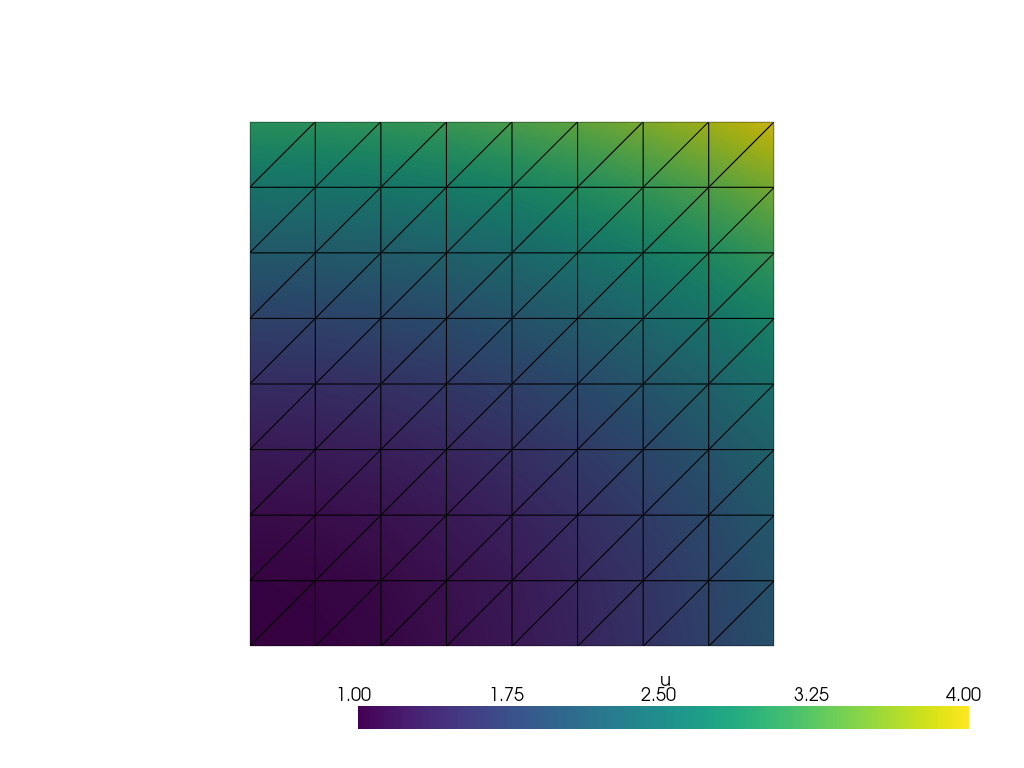

In [6]:
import pyvista as pv
from dolfinx.plot import vtk_mesh

pv.set_jupyter_backend("static")

topology, cell_types, geometry = vtk_mesh(V)
grid = pv.UnstructuredGrid(topology, cell_types, geometry)
grid.point_data["u"] = uh.x.array.real

plotter = pv.Plotter()
plotter.add_mesh(grid, show_edges=True, scalars="u", cmap="viridis")
plotter.view_xy()
plotter.show()